In [1]:
# Verificar qué hay en la carpeta models
import os
print(os.listdir("../models"))

['.gitignore', '.ipynb_checkpoints', '09_models.ipynb', 'baseline_decision_tree.pkl', 'baseline_knn.pkl', 'baseline_logistic_regression.pkl', 'baseline_random_forest.pkl', 'baseline_svm.pkl', 'preprocessing_pipeline.pkl', 'preprocessing_pipeline.pkl.dvc']


In [1]:
import joblib
import os

print("🔍 Cargando modelo...")
modelo = joblib.load("../models/baseline_logistic_regression.pkl")
print("✅ ÉXITO: Modelo cargado")
print(f"   Tipo: {type(modelo)}")

🔍 Cargando modelo...
✅ ÉXITO: Modelo cargado
   Tipo: <class 'imblearn.pipeline.Pipeline'>


C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.2 when us

✅ Librerías cargadas

📂 Cargando datos raw...
✅ Datos raw: (10000, 18)
🎯 Target: Revenue

🛠️ Preprocesando datos...
✅ X_scaled shape: (10000, 14)
📊 Train: 8000, Test: 2000

📊 EVALUACIÓN DE MODELOS BASELINE (siguiendo ejemplo)

🔍 MODELO: Logistic Regression

📊 CROSS-VALIDATION (5-fold):
   F1 (CV):      0.5108 +/- 0.0379
   Accuracy CV:  0.8930 +/- 0.0081
   Precision CV: 0.7492 +/- 0.0572
   Recall CV:    0.3877 +/- 0.0297
   ROC_AUC CV:   0.8937 +/- 0.0141

📊 MÉTRICAS EN TEST:
   Accuracy:  0.8960
   Precision: 0.8030
   Recall:    0.3681
   F1-Score:  0.5048
   AUC-ROC:   0.8925

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No Revenue       0.90      0.98      0.94      1712
     Revenue       0.80      0.37      0.50       288

    accuracy                           0.90      2000
   macro avg       0.85      0.68      0.72      2000
weighted avg       0.89      0.90      0.88      2000


📊 CONFUSION MATRIX:
              Predicho: No   Predicho:

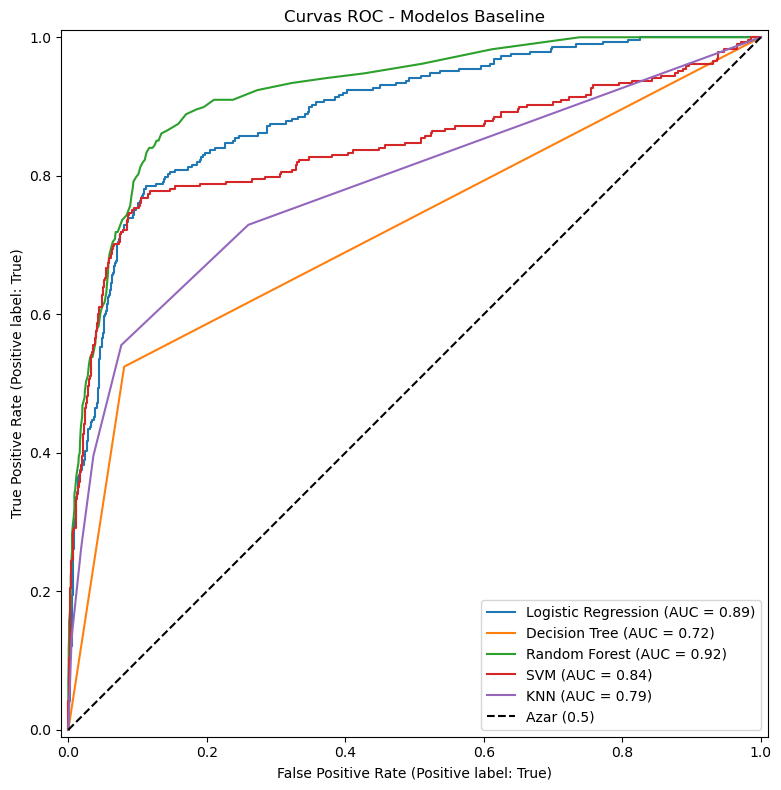


📊 GENERANDO MATRICES DE CONFUSIÓN...


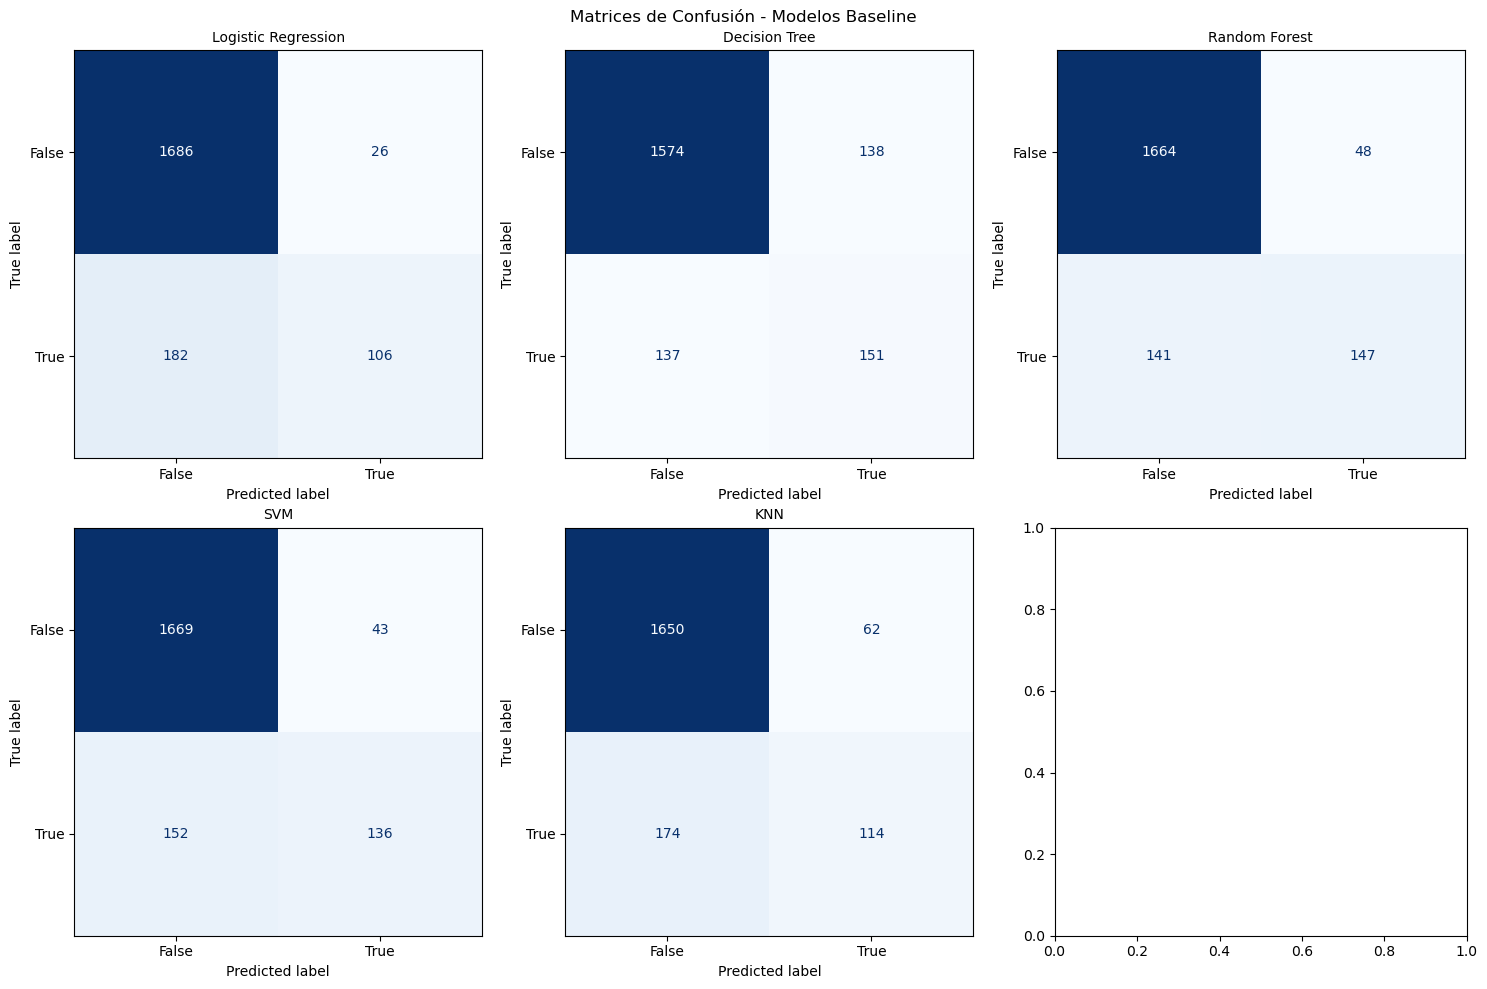


📋 CONCLUSIONES - PB-11

🏆 MEJOR MODELO: Random Forest
   F1-Score en TEST: 0.6087
   F1-Score CV:      0.6294 +/- 0.0436
   Accuracy en TEST: 0.9055

✅ PB-11 COMPLETADO (siguiendo el ejemplo)


In [3]:
# ============================================
# PB-11 - Siguiendo el ejemplo 
# ============================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, make_scorer,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

# ============================================
# 1. CARGAR DATOS RAW
# ============================================
print("\n📂 Cargando datos raw...")
df_raw = pd.read_csv("../data/raw/dataset_pucp.csv", nrows=10000)
print(f"✅ Datos raw: {df_raw.shape}")

target = 'Revenue' if 'Revenue' in df_raw.columns else df_raw.columns[-1]
print(f"🎯 Target: {target}")

y = df_raw[target]
X_raw = df_raw.drop(columns=[target])

# ============================================
# 2. PREPROCESAMIENTO MANUAL
# ============================================
print("\n🛠️ Preprocesando datos...")
X = X_raw.select_dtypes(include=[np.number])

for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✅ X_scaled shape: {X_scaled.shape}")

# ============================================
# 3. DIVIDIR EN TRAIN Y TEST
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"📊 Train: {len(X_train)}, Test: {len(X_test)}")

# ============================================
# 4. DEFINIR MODELOS 
# ============================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier()
}

# ============================================
# 5. CONFIGURACIÓN DE CROSS-VALIDATION 
# ============================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
}

# ============================================
# 6. EVALUAR CADA MODELO CON cross_validate
# ============================================
print("\n" + "="*80)
print("📊 EVALUACIÓN DE MODELOS BASELINE (siguiendo ejemplo)")
print("="*80)

resultados = []

for name, pipe in models.items():
    print(f"\n{'='*60}")
    print(f"🔍 MODELO: {name}")
    print(f"{'='*60}")
    
    # ========================================
    # CROSS-VALIDATION 
    # ========================================
    results = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True
    )
    
    print(f"\n📊 CROSS-VALIDATION (5-fold):")
    print(f"   F1 (CV):      {results['test_f1'].mean():.4f} +/- {results['test_f1'].std():.4f}")
    print(f"   Accuracy CV:  {results['test_accuracy'].mean():.4f} +/- {results['test_accuracy'].std():.4f}")
    print(f"   Precision CV: {results['test_precision'].mean():.4f} +/- {results['test_precision'].std():.4f}")
    print(f"   Recall CV:    {results['test_recall'].mean():.4f} +/- {results['test_recall'].std():.4f}")
    print(f"   ROC_AUC CV:   {results['test_roc_auc'].mean():.4f} +/- {results['test_roc_auc'].std():.4f}")
    
    # ========================================
    # ENTRENAR Y EVALUAR EN TEST
    # ========================================
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None
    
    print(f"\n📊 MÉTRICAS EN TEST:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    if auc:
        print(f"   AUC-ROC:   {auc:.4f}")
    
    # ========================================
    # CLASSIFICATION REPORT
    # ========================================
    print(f"\n📊 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['No Revenue', 'Revenue']))
    
    # ========================================
    # CONFUSION MATRIX (impresa)
    # ========================================
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n📊 CONFUSION MATRIX:")
    print(f"              Predicho: No   Predicho: Sí")
    print(f"   Real: No      {cm[0,0]:4d}          {cm[0,1]:4d}")
    print(f"   Real: Sí      {cm[1,0]:4d}          {cm[1,1]:4d}")
    
    # Guardar resultados
    resultados.append({
        'Modelo': name,
        'Accuracy_Test': round(acc, 4),
        'Precision_Test': round(prec, 4),
        'Recall_Test': round(rec, 4),
        'F1_Test': round(f1, 4),
        'AUC_Test': round(auc, 4) if auc else None,
        'F1_CV_Mean': round(results['test_f1'].mean(), 4),
        'F1_CV_Std': round(results['test_f1'].std(), 4)
    })

# ============================================
# 7. TABLA COMPARATIVA FINAL
# ============================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1_Test', ascending=False)

print("\n" + "="*80)
print("📈 TABLA COMPARATIVA DE MODELOS (ordenada por F1-Score en TEST)")
print("="*80)
print(df_resultados.to_string(index=False))

# ============================================
# 8. CURVAS ROC 
# ============================================
print("\n📊 GENERANDO CURVAS ROC...")
fig, ax = plt.subplots(figsize=(10, 8))

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Azar (0.5)')
ax.set_title('Curvas ROC - Modelos Baseline')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ============================================
# 9. MATRICES DE CONFUSIÓN 
# ============================================
print("\n📊 GENERANDO MATRICES DE CONFUSIÓN...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (name, pipe) in zip(axes.ravel(), models.items()):
    pipe.fit(X_train, y_train)
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        ax=ax, cmap='Blues',
        colorbar=False
    )
    ax.set_title(name, fontsize=10)

plt.suptitle('Matrices de Confusión - Modelos Baseline')
plt.tight_layout()
plt.show()

# ============================================
# 10. CONCLUSIONES
# ============================================
print("\n" + "="*80)
print("📋 CONCLUSIONES - PB-11")
print("="*80)

mejor = df_resultados.iloc[0]
print(f"\n🏆 MEJOR MODELO: {mejor['Modelo']}")
print(f"   F1-Score en TEST: {mejor['F1_Test']:.4f}")
print(f"   F1-Score CV:      {mejor['F1_CV_Mean']:.4f} +/- {mejor['F1_CV_Std']:.4f}")
print(f"   Accuracy en TEST: {mejor['Accuracy_Test']:.4f}")

print("\n" + "="*80)
print("✅ PB-11 COMPLETADO (siguiendo el ejemplo)")
print("="*80)